# Variational Autoencoder (VAE)

**Thực hành cơ bản về VAE**

Notebook này bao gồm các nội dung:
- Encoder: Ánh xạ dữ liệu vào phân phối không gian tiềm ẩn (latent distribution).
- Reparameterization trick (Thủ thuật tham số hóa lại).
- Decoder: Ánh xạ từ không gian tiềm ẩn ra ảnh tái tạo.
- VAE loss = Reconstruction loss + KL divergence.
- Trực quan hóa không gian tiềm ẩn (Latent space visualization).
- Nội suy (Interpolation) và Sinh mẫu mới (Generating new samples).

---

**Setup & Imports**




In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LATENT_DIM = 2  # Sử dụng 2D để dễ dàng trực quan hóa
print(f'Device: {device}')

Device: cuda


## 1. Chuẩn bị dữ liệu (Dataset & DataLoader)
Sử dụng tập dữ liệu ảnh chữ số viết tay MNIST (ảnh grayscale $28 \times 28$).

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])
train_data = torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform)
val_data = torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=512, shuffle=False)
print(f'Input shape: {train_data[0][0].shape}')  # Kết quả mong đợi: (1, 28, 28)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 338kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]

Input shape: torch.Size([1, 28, 28])


## 2. Define VAE (Xây dựng mô hình VAE)



Dưới đây là sơ đồ kiến trúc của VAE:





<p align="center">

  <img src="https://www.researchgate.net/publication/370687768/figure/fig1/AS:11431281202080338@1698723661544/The-fundamental-mechanisms-of-the-VAE-a-and-CVAE-b.png" width="700">

</p>



**Mapping Lý thuyết & Code:**

1. **Encoder:** Tính toán giá trị trung bình $\mu$ (mu) và phương sai $\sigma^2$ (được biểu diễn qua log-variance `logvar` để đảm bảo tính ổn định).

2. **Reparameterization Trick:** Vì không thể tính đạo hàm qua một quá trình lấy mẫu ngẫu nhiên (sampling), ta dùng trick:

   $$z = \mu + \sigma \odot \epsilon$$

   Trong đó $\epsilon \sim \mathcal{N}(0, 1)$ (một nhiễu Gaussian chuẩn).

3. **Decoder:** Tái tạo lại ảnh từ vector tiềm ẩn (latent vector) $z$.

" width="700">

In [ ]:
class CVAE(nn.Module):
    def __init__(self, latent_dim: int = 2, num_classes: int = 10):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        # --- Encoder ---
        # Input bây giờ là 784 (ảnh) + 10 (vector one-hot của nhãn) = 794
        self.encoder = nn.Sequential(
            nn.Linear(784 + num_classes, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # --- Decoder ---
        # Input bây giờ là latent_dim (2) + 10 (vector one-hot của nhãn) = 12
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid()
        )

    def encode(self, x, c):
        # Nối ảnh x và nhãn c lại với nhau
        inputs = torch.cat([x, c], dim=1)
        h = self.encoder(inputs)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c):
        # Nối vector tiềm ẩn z và nhãn c lại với nhau
        inputs = torch.cat([z, c], dim=1)
        return self.decoder(inputs).view(-1, 1, 28, 28)

    def forward(self, x, c):
        x = x.view(x.size(0), -1)
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z, c)
        return x_recon, mu, logvar

model_cvae = CVAE(latent_dim=LATENT_DIM).to(device)
print(model_cvae)

CVAE(
  (encoder): Sequential(
    (0): Linear(in_features=794, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=256, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


## 3. VAE Loss Function
Hàm mục tiêu ELBO bao gồm:
1. **Reconstruction loss (BCE):** Đánh giá mức độ khớp giữa ảnh tái tạo và ảnh gốc.
2. **KL Divergence loss:** Ép phân phối của latent space xấp xỉ với phân phối chuẩn.

In [ ]:
def vae_loss(x_recon, x, mu, logvar, beta=1.0):
    # Reconstruction loss (BCE)
    recon_loss = F.binary_cross_entropy(x_recon.view(-1, 784), x.view(-1, 784), reduction='sum')

    # KL Divergence loss
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Trung bình trên batch
    batch_size = x.size(0)
    recon_loss /= batch_size
    kl_loss /= batch_size

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

## 4. Training Loop (Vòng lặp huấn luyện)
Sử dụng Adam Optimizer với learning rate = 1e-3, huấn luyện trong 10 epochs.

In [ ]:
optimizer = torch.optim.Adam(model_cvae.parameters(), lr=1e-3)
epochs = 10

model_cvae.train()
for epoch in range(epochs):
    train_loss, train_recon, train_kl = 0.0, 0.0, 0.0

    # LẤY THÊM NHÃN (labels) TỪ DATASET
    for x, labels in train_loader:
        x = x.to(device)

        # CHUYỂN NHÃN THÀNH ONE-HOT VECTOR LÀM ĐIỀU KIỆN (c)
        c = F.one_hot(labels, num_classes=10).float().to(device)

        optimizer.zero_grad()

        # TRUYỀN CẢ x VÀ c VÀO MODEL
        x_recon, mu, logvar = model_cvae(x, c)

        loss, recon_loss, kl_loss = vae_loss(x_recon, x, mu, logvar)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_recon += recon_loss.item()
        train_kl += kl_loss.item()

    num_batches = len(train_loader)
    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Total Loss: {train_loss/num_batches:.4f} | "
          f"Recon: {train_recon/num_batches:.4f} | "
          f"KL: {train_kl/num_batches:.4f}")

Epoch 01/10 | Total Loss: 168.8224 | Recon: 165.3605 | KL: 3.4619
Epoch 02/10 | Total Loss: 141.2762 | Recon: 137.1638 | KL: 4.1124
Epoch 03/10 | Total Loss: 136.3822 | Recon: 132.0473 | KL: 4.3349
Epoch 04/10 | Total Loss: 134.0118 | Recon: 129.5432 | KL: 4.4686
Epoch 05/10 | Total Loss: 132.6407 | Recon: 128.0600 | KL: 4.5807
Epoch 06/10 | Total Loss: 131.7701 | Recon: 127.1529 | KL: 4.6172
Epoch 07/10 | Total Loss: 131.1497 | Recon: 126.4832 | KL: 4.6665
Epoch 08/10 | Total Loss: 130.6126 | Recon: 125.8966 | KL: 4.7160
Epoch 09/10 | Total Loss: 130.1939 | Recon: 125.4469 | KL: 4.7471
Epoch 10/10 | Total Loss: 129.8430 | Recon: 125.0673 | KL: 4.7757


## 5. Visualize Reconstructions (Trực quan hóa ảnh tái tạo)
So sánh ảnh gốc (Original) và ảnh được mạng VAE tái tạo lại (Reconstructed).

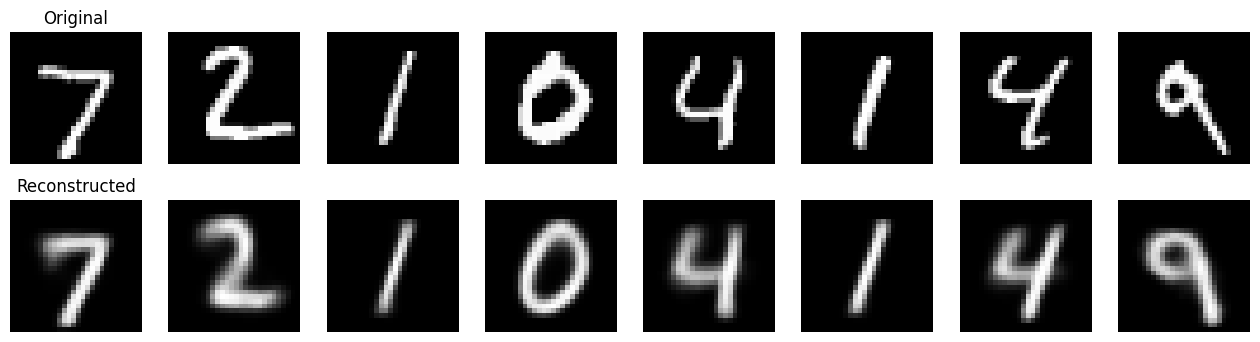

In [ ]:
model_cvae.eval() # Dùng đúng tên model_cvae
with torch.no_grad():
    # 1. Lấy cả dữ liệu (data) và nhãn (labels) từ val_loader
    data, labels = next(iter(val_loader))
    data = data.to(device)

    # 2. Tạo biến điều kiện c (one-hot vector) từ nhãn
    c = F.one_hot(labels, num_classes=10).float().to(device)

    # 3. Đưa CẢ ảnh (data) và điều kiện (c) vào model
    recon_data, _, _ = model_cvae(data, c)

    n = 8
    plt.figure(figsize=(16, 4))
    for i in range(n):
        # Ảnh gốc
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(data[i].cpu().squeeze(), cmap='gray')
        ax.axis('off')
        if i == 0: ax.set_title("Original")

        # Ảnh tái tạo
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(recon_data[i].cpu().squeeze(), cmap='gray')
        ax.axis('off')
        if i == 0: ax.set_title("Reconstructed")
    plt.show()

## 6. Latent Space Visualization (Trực quan hóa không gian tiềm ẩn)
Chiếu toàn bộ tập Validation xuống không gian 2D để xem VAE phân cụm các chữ số như thế nào.

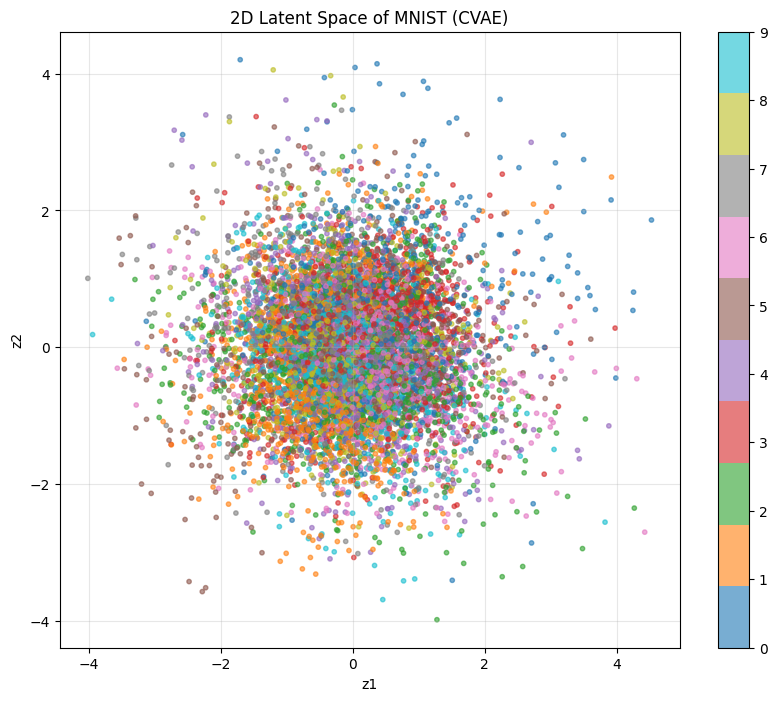

In [ ]:
model_cvae.eval()
z_points = []
labels_list = []

with torch.no_grad():
    for x, labels in val_loader:
        x = x.to(device)

        # 1. Tạo biến điều kiện c
        c = F.one_hot(labels, num_classes=10).float().to(device)

        # 2. Làm phẳng ảnh x từ 4D (batch, 1, 28, 28) thành 2D (batch, 784)
        x_flat = x.view(x.size(0), -1)

        # 3. Truyền x_flat và c vào hàm encode
        mu, _ = model_cvae.encode(x_flat, c)

        z_points.append(mu.cpu().numpy())
        labels_list.append(labels.numpy())

z_points = np.concatenate(z_points, axis=0)
labels_list = np.concatenate(labels_list, axis=0)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(z_points[:, 0], z_points[:, 1], c=labels_list, cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, ticks=range(10))
plt.title("2D Latent Space of MNIST (CVAE)")
plt.xlabel("z1")
plt.ylabel("z2")
plt.grid(True, alpha=0.3)
plt.show()

## 7. Latent Interpolation (Nội suy trong không gian tiềm ẩn)
Kiểm tra tính liên tục của Latent Space bằng cách chuyển dần từ chữ số này sang chữ số khác.

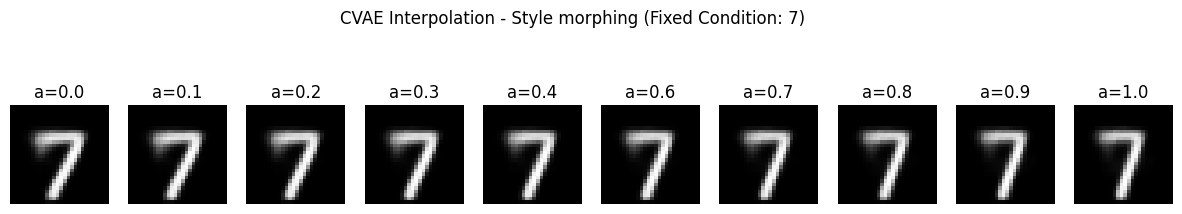

In [ ]:
model_cvae.eval()
with torch.no_grad():
    x, labels = next(iter(val_loader))
    x1, x2 = x[0].to(device), x[3].to(device) # Chọn 2 ảnh bất kỳ

    # 1. Lấy nhãn thực tế của 2 ảnh và chuyển thành one-hot vector cho Encoder
    c1 = F.one_hot(labels[0].unsqueeze(0), num_classes=10).float().to(device)
    c2 = F.one_hot(labels[3].unsqueeze(0), num_classes=10).float().to(device)

    # --- FIX LỖI TẠI ĐÂY ---
    # Làm phẳng ảnh x1, x2 thành 2D kích thước (1, 784)
    x1_flat = x1.view(1, -1)
    x2_flat = x2.view(1, -1)

    # 2. Truyền CẢ ảnh phẳng và nhãn vào Encoder để lấy z1, z2
    mu1, _ = model_cvae.encode(x1_flat, c1)
    mu2, _ = model_cvae.encode(x2_flat, c2)

    # 3. CHỌN ĐIỀU KIỆN (c) CỐ ĐỊNH CHO DECODER
    # Ép quá trình nội suy phải mang hình hài của chữ số ở ảnh đầu tiên
    c_decode = c1
    label_name = labels[0].item()

    steps = 10
    alphas = torch.linspace(0, 1, steps).to(device)

    plt.figure(figsize=(15, 3))
    for i, alpha in enumerate(alphas):
        # Nội suy tuyến tính vector z
        z_interp = (1 - alpha) * mu1 + alpha * mu2

        # 4. Giải mã: Đưa cả z_interp VÀ c_decode vào Decoder
        recon_interp = model_cvae.decode(z_interp, c_decode)

        ax = plt.subplot(1, steps, i + 1)
        plt.imshow(recon_interp.cpu().squeeze(), cmap='gray')
        ax.axis('off')
        ax.set_title(f"a={alpha.item():.1f}")

    plt.suptitle(f"CVAE Interpolation - Style morphing (Fixed Condition: {label_name})")
    plt.show()

## 8. Generate New Samples (Sinh mẫu mới)
Lấy các vector ngẫu nhiên $z \sim \mathcal{N}(0, I)$ đưa qua Decoder để tạo ra những chữ số chưa từng tồn tại.

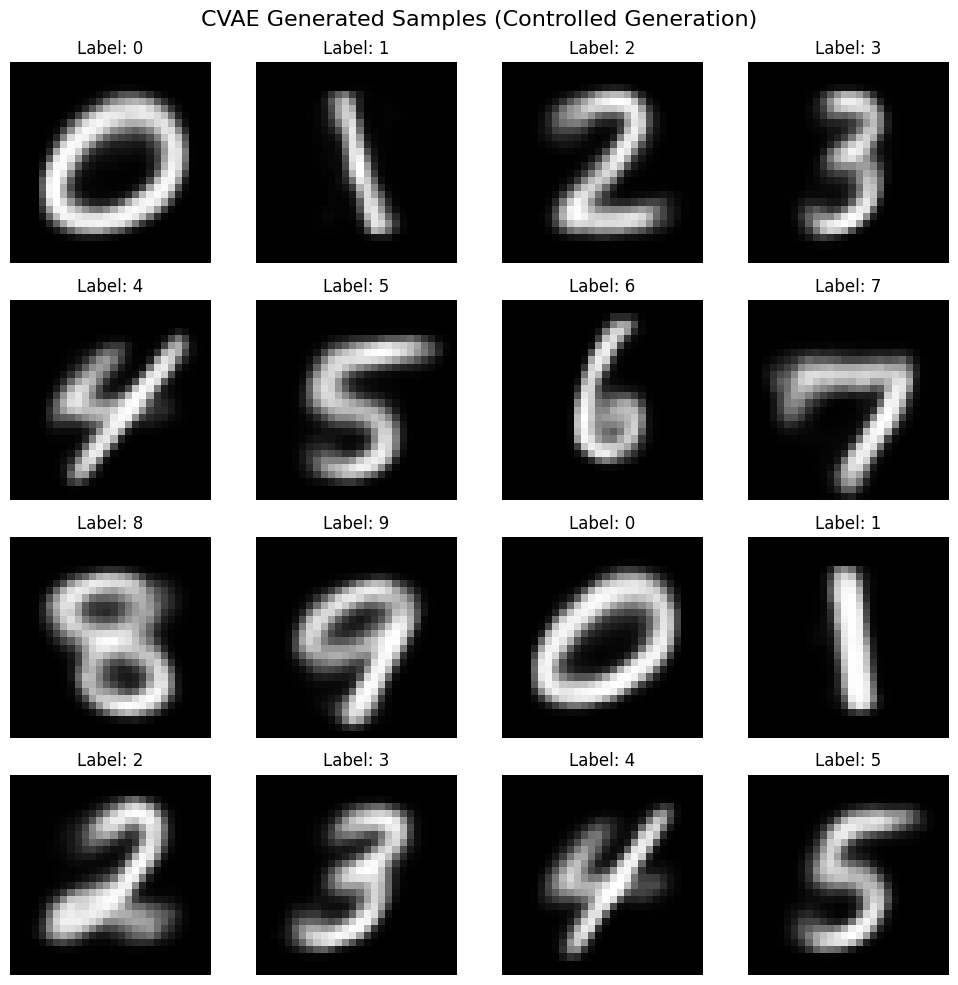

In [ ]:
model_cvae.eval()
with torch.no_grad():
    # 1. Lấy mẫu 16 vector z ngẫu nhiên từ phân phối chuẩn
    z_random = torch.randn(16, LATENT_DIM).to(device)

    # 2. CHỈ ĐỊNH ĐIỀU KIỆN CỤ THỂ
    # Ép máy phải vẽ lần lượt các số: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1...
    desired_labels = torch.tensor([i % 10 for i in range(16)])

    # Chuyển nhãn thành one-hot vector
    c_random = F.one_hot(desired_labels, num_classes=10).float().to(device)

    # 3. Đưa cả z (phong cách ngẫu nhiên) và c (nhãn bắt buộc) vào Decoder
    generated_images = model_cvae.decode(z_random, c_random)

    # Trực quan hóa
    plt.figure(figsize=(10, 10))
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(generated_images[i].cpu().squeeze(), cmap='gray')
        ax.axis('off')
        # In thêm cái nhãn lên đầu mỗi ảnh để sinh viên dễ đối chiếu
        ax.set_title(f"Label: {desired_labels[i].item()}")

    plt.suptitle("CVAE Generated Samples (Controlled Generation)", fontsize=16)
    plt.tight_layout()
    plt.show()